In [2]:
# ============================================
# CELL 1 - Imports
# ============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_score, recall_score,
    f1_score, roc_auc_score,
    confusion_matrix, roc_curve
)
import mlflow
import mlflow.pytorch
import warnings
warnings.filterwarnings('ignore')

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Libraries imported!")
print(f"🖥️  Using device: {device}")

✅ Libraries imported!
🖥️  Using device: cpu


In [3]:
# ============================================
# CELL 2 - Load Data
# ============================================

cols = ['engine_id', 'cycle'] + \
       [f'setting_{i}' for i in range(1, 4)] + \
       [f'sensor_{i}' for i in range(1, 22)]

train_df = pd.read_csv(
    '../data/train_FD001.txt',
    sep='\s+',
    header=None,
    names=cols,
    engine='python'
)
train_df.dropna(axis=1, how='all', inplace=True)

# Add RUL
max_cycle = train_df.groupby('engine_id')['cycle'].max().reset_index()
max_cycle.columns = ['engine_id', 'max_cycle']
train_df = train_df.merge(max_cycle, on='engine_id')
train_df['RUL'] = train_df['max_cycle'] - train_df['cycle']
train_df.drop(columns=['max_cycle'], inplace=True)
train_df['failure_label'] = (train_df['RUL'] < 30).astype(int)

# Get useful sensors
sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
sensor_cols = [c for c in sensor_cols
               if c in train_df.columns
               and train_df[c].std() > 0.001]

print(f"✅ Data loaded: {train_df.shape}")
print(f"📊 Useful sensors: {len(sensor_cols)}")
print(f"📊 Normal samples : {(train_df['failure_label']==0).sum()}")
print(f"📊 Anomaly samples: {(train_df['failure_label']==1).sum()}")

✅ Data loaded: (20631, 28)
📊 Useful sensors: 15
📊 Normal samples : 17631
📊 Anomaly samples: 3000


In [4]:
# ============================================
# CELL 3 - Scale Features
# ============================================

# Features
X_all   = train_df[sensor_cols].fillna(0).values
y_all   = train_df['failure_label'].values

# Split normal vs anomaly
X_normal  = X_all[y_all == 0]
X_anomaly = X_all[y_all == 1]

# Train/test split
train_size    = int(len(X_normal) * 0.7)
X_train       = X_normal[:train_size]
X_test_normal = X_normal[train_size:]

# Scale
scaler        = StandardScaler()
X_train_sc    = scaler.fit_transform(X_train)
X_test_norm_sc= scaler.transform(X_test_normal)
X_anomaly_sc  = scaler.transform(X_anomaly)
X_all_sc      = scaler.transform(X_all)

print(f"✅ X_train shape    : {X_train_sc.shape}")
print(f"✅ X_test_norm shape: {X_test_norm_sc.shape}")
print(f"✅ X_anomaly shape  : {X_anomaly_sc.shape}")
print(f"✅ Input features   : {X_train_sc.shape[1]}")

✅ X_train shape    : (12341, 15)
✅ X_test_norm shape: (5290, 15)
✅ X_anomaly shape  : (3000, 15)
✅ Input features   : 15


In [5]:
# ============================================
# CELL 4 - LSTM Autoencoder Architecture
# ============================================

class LSTMAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, latent_dim=32):
        super(LSTMAutoencoder, self).__init__()

        self.input_dim  = input_dim
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim

        # Encoder
        self.encoder_lstm1 = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True
        )
        self.encoder_lstm2 = nn.LSTM(
            input_size=hidden_dim,
            hidden_size=latent_dim,
            num_layers=1,
            batch_first=True
        )

        # Decoder
        self.decoder_lstm1 = nn.LSTM(
            input_size=latent_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True
        )
        self.decoder_lstm2 = nn.LSTM(
            input_size=hidden_dim,
            hidden_size=input_dim,
            num_layers=1,
            batch_first=True
        )

        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        # x shape: (batch, seq_len, input_dim)

        # Encode
        enc1, _ = self.encoder_lstm1(x)
        enc1    = self.dropout(enc1)
        enc2, _ = self.encoder_lstm2(enc1)

        # Decode
        dec1, _ = self.decoder_lstm1(enc2)
        dec1    = self.dropout(dec1)
        dec2, _ = self.decoder_lstm2(dec1)

        return dec2

# Initialize model
input_dim = X_train_sc.shape[1]
model     = LSTMAutoencoder(
    input_dim=input_dim,
    hidden_dim=64,
    latent_dim=32
).to(device)

print("✅ LSTM Autoencoder Architecture:")
print(model)
print(f"\n📊 Input dimension : {input_dim}")
total_params = sum(p.numel() for p in model.parameters())
print(f"📊 Total parameters: {total_params:,}")

✅ LSTM Autoencoder Architecture:
LSTMAutoencoder(
  (encoder_lstm1): LSTM(15, 64, batch_first=True)
  (encoder_lstm2): LSTM(64, 32, batch_first=True)
  (decoder_lstm1): LSTM(32, 64, batch_first=True)
  (decoder_lstm2): LSTM(64, 15, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
)

📊 Input dimension : 15
📊 Total parameters: 63,228


In [6]:
# ============================================
# CELL 5 - Prepare DataLoader
# ============================================

SEQ_LEN    = 1  # single timestep (can increase later)
BATCH_SIZE = 64

def prepare_sequences(X, seq_len=1):
    """Reshape data for LSTM: (samples, seq_len, features)"""
    X_tensor = torch.FloatTensor(X).unsqueeze(1)
    return X_tensor

# Prepare tensors
X_train_tensor = prepare_sequences(X_train_sc)
X_test_tensor  = prepare_sequences(X_all_sc)

# Create datasets
train_dataset = TensorDataset(X_train_tensor, X_train_tensor)
train_loader  = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

print(f"✅ Train tensor shape: {X_train_tensor.shape}")
print(f"✅ Test tensor shape : {X_test_tensor.shape}")
print(f"✅ Batches per epoch : {len(train_loader)}")

✅ Train tensor shape: torch.Size([12341, 1, 15])
✅ Test tensor shape : torch.Size([20631, 1, 15])
✅ Batches per epoch : 193


In [7]:
# ============================================
# CELL 6 - Train Model
# ============================================

EPOCHS    = 30
LR        = 0.001

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer, step_size=10, gamma=0.5
)

train_losses = []

print("🔄 Training LSTM Autoencoder...")
print(f"   Epochs    : {EPOCHS}")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Device    : {device}\n")

mlflow.set_experiment("anomaly_detection")

with mlflow.start_run(run_name="LSTM_Autoencoder"):

    mlflow.log_params({
        "model"      : "LSTM_Autoencoder",
        "epochs"     : EPOCHS,
        "batch_size" : BATCH_SIZE,
        "lr"         : LR,
        "hidden_dim" : 64,
        "latent_dim" : 32
    })

    for epoch in range(EPOCHS):
        model.train()
        epoch_loss = 0

        for batch_X, batch_y in train_loader:
            batch_X = batch_X.to(device)

            # Forward pass
            reconstructed = model(batch_X)
            loss = criterion(reconstructed, batch_X)

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_loss)
        scheduler.step()

        # Log to MLflow
        mlflow.log_metric("train_loss", avg_loss, step=epoch)

        if (epoch + 1) % 5 == 0:
            print(f"  Epoch [{epoch+1:3d}/{EPOCHS}] "
                  f"Loss: {avg_loss:.6f}")

    print(f"\n✅ Training complete!")
    print(f"📊 Final loss: {train_losses[-1]:.6f}")

🔄 Training LSTM Autoencoder...
   Epochs    : 30
   Batch size: 64
   Device    : cpu

  Epoch [  5/30] Loss: 0.442080
  Epoch [ 10/30] Loss: 0.364295
  Epoch [ 15/30] Loss: 0.342840
  Epoch [ 20/30] Loss: 0.334297
  Epoch [ 25/30] Loss: 0.331123
  Epoch [ 30/30] Loss: 0.328845

✅ Training complete!
📊 Final loss: 0.328845


In [8]:
# ============================================
# CELL 7 - Reconstruction Error & Threshold
# ============================================

model.eval()

with torch.no_grad():
    X_test_t  = X_test_tensor.to(device)
    recon     = model(X_test_t)
    recon_err = torch.mean(
        (X_test_t - recon) ** 2,
        dim=(1, 2)
    ).cpu().numpy()

print(f"✅ Reconstruction errors computed!")
print(f"📊 Min error  : {recon_err.min():.6f}")
print(f"📊 Max error  : {recon_err.max():.6f}")
print(f"📊 Mean error : {recon_err.mean():.6f}")

# Set threshold (95th percentile of normal data)
normal_errors = recon_err[y_all == 0]
threshold     = np.percentile(normal_errors, 95)
print(f"\n🎯 Anomaly threshold (95th percentile): {threshold:.6f}")

# Predict anomalies
lstm_preds = (recon_err > threshold).astype(int)

# Normalize for ROC-AUC
recon_norm = (recon_err - recon_err.min()) / \
             (recon_err.max() - recon_err.min() + 1e-8)

# Metrics
lstm_precision = precision_score(y_all, lstm_preds, zero_division=0)
lstm_recall    = recall_score(y_all, lstm_preds, zero_division=0)
lstm_f1        = f1_score(y_all, lstm_preds, zero_division=0)
lstm_roc_auc   = roc_auc_score(y_all, recon_norm)

print(f"\n📊 LSTM Autoencoder Results:")
print(f"  Precision : {lstm_precision:.4f}")
print(f"  Recall    : {lstm_recall:.4f}")
print(f"  F1 Score  : {lstm_f1:.4f}")
print(f"  ROC-AUC   : {lstm_roc_auc:.4f}")

with mlflow.start_run(run_name="LSTM_Autoencoder_Eval"):
    mlflow.log_metrics({
        "precision": lstm_precision,
        "recall"   : lstm_recall,
        "f1_score" : lstm_f1,
        "roc_auc"  : lstm_roc_auc,
        "threshold": threshold
    })

✅ Reconstruction errors computed!
📊 Min error  : 0.002868
📊 Max error  : 30.676273
📊 Mean error : 0.750529

🎯 Anomaly threshold (95th percentile): 1.128402

📊 LSTM Autoencoder Results:
  Precision : 0.7468
  Recall    : 0.8670
  F1 Score  : 0.8024
  ROC-AUC   : 0.9731


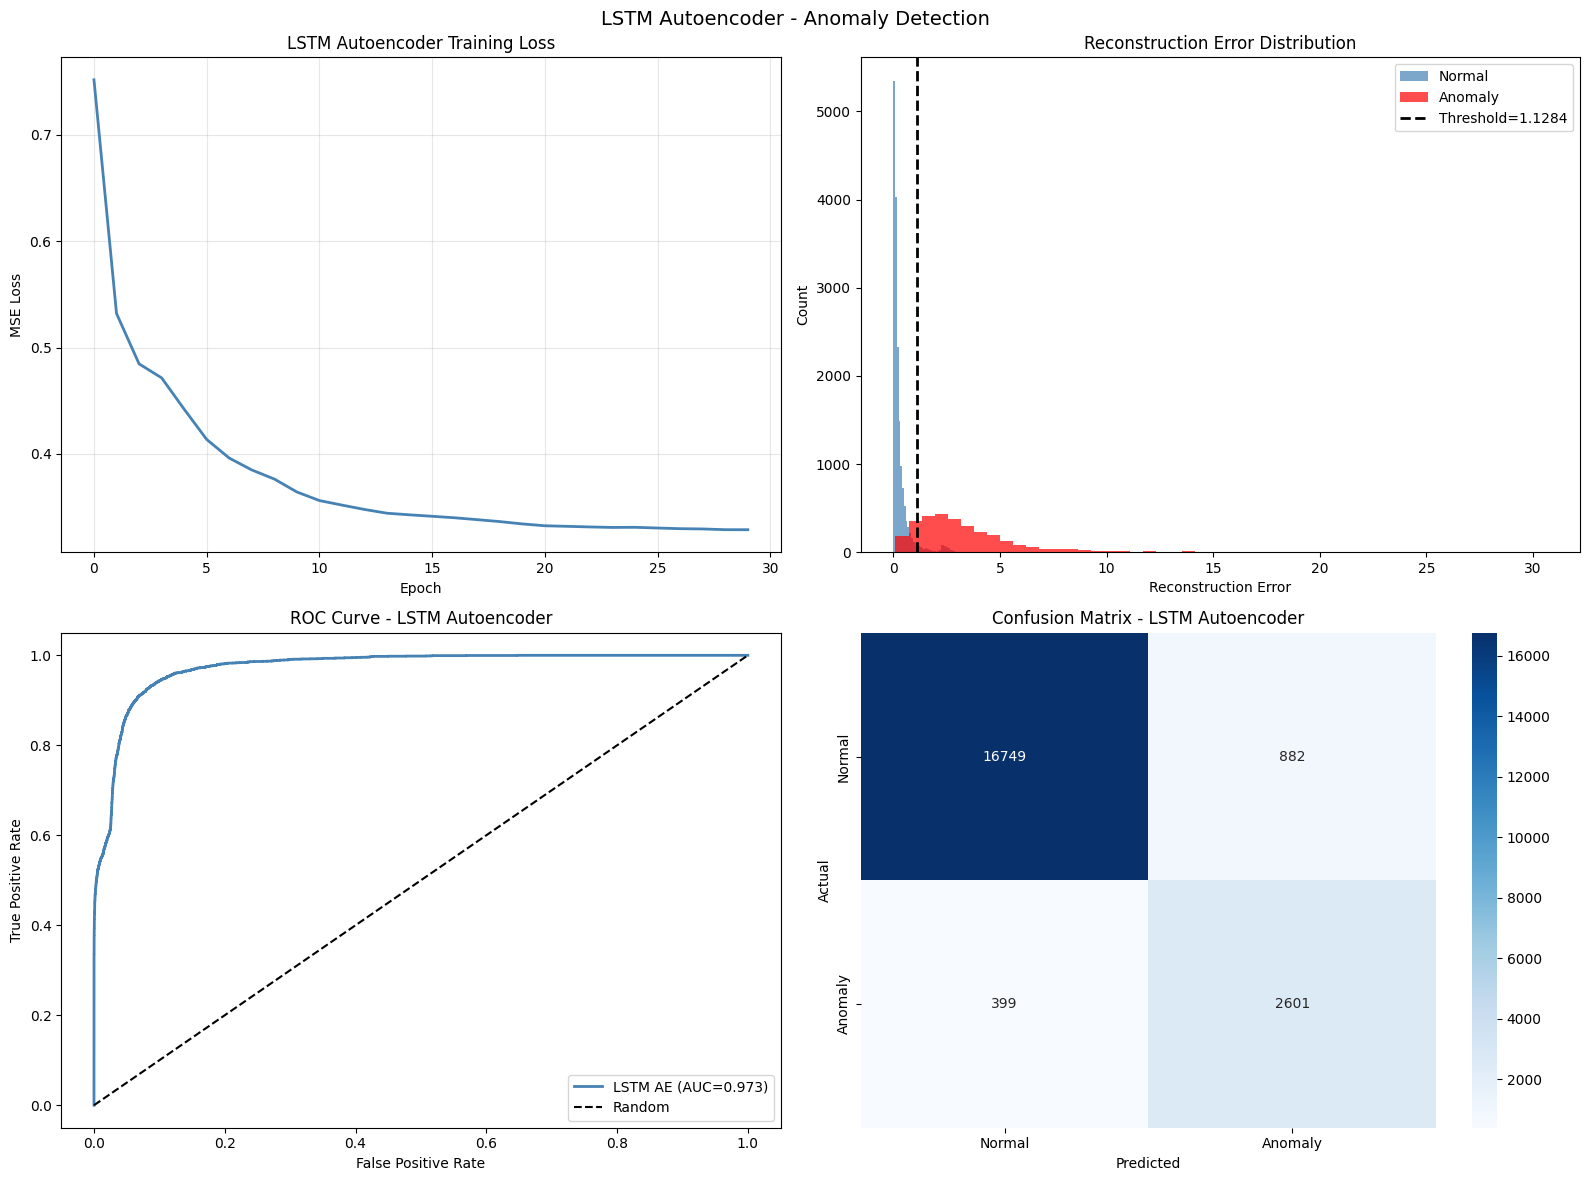

✅ Plots saved!


In [9]:
# ============================================
# CELL 8 - Visualizations
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Training Loss
axes[0,0].plot(train_losses, color='steelblue', linewidth=2)
axes[0,0].set_title('LSTM Autoencoder Training Loss')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('MSE Loss')
axes[0,0].grid(True, alpha=0.3)

# Plot 2: Reconstruction Error Distribution
axes[0,1].hist(
    recon_err[y_all==0],
    bins=50, alpha=0.7,
    color='steelblue',
    label='Normal'
)
axes[0,1].hist(
    recon_err[y_all==1],
    bins=50, alpha=0.7,
    color='red',
    label='Anomaly'
)
axes[0,1].axvline(
    threshold,
    color='black',
    linestyle='--',
    linewidth=2,
    label=f'Threshold={threshold:.4f}'
)
axes[0,1].set_title('Reconstruction Error Distribution')
axes[0,1].set_xlabel('Reconstruction Error')
axes[0,1].set_ylabel('Count')
axes[0,1].legend()

# Plot 3: ROC Curve
fpr, tpr, _ = roc_curve(y_all, recon_norm)
axes[1,0].plot(fpr, tpr,
               color='steelblue', linewidth=2,
               label=f'LSTM AE (AUC={lstm_roc_auc:.3f})')
axes[1,0].plot([0,1],[0,1],'k--', label='Random')
axes[1,0].set_title('ROC Curve - LSTM Autoencoder')
axes[1,0].set_xlabel('False Positive Rate')
axes[1,0].set_ylabel('True Positive Rate')
axes[1,0].legend()

# Plot 4: Confusion Matrix
cm = confusion_matrix(y_all, lstm_preds)
sns.heatmap(cm, annot=True, fmt='d',
            cmap='Blues', ax=axes[1,1])
axes[1,1].set_title('Confusion Matrix - LSTM Autoencoder')
axes[1,1].set_xlabel('Predicted')
axes[1,1].set_ylabel('Actual')
axes[1,1].set_xticklabels(['Normal', 'Anomaly'])
axes[1,1].set_yticklabels(['Normal', 'Anomaly'])

plt.suptitle('LSTM Autoencoder - Anomaly Detection', fontsize=14)
plt.tight_layout()
plt.savefig('../notebooks/lstm_autoencoder_results.png', dpi=150)
plt.show()
print("✅ Plots saved!")

In [11]:
# ============================================
# CELL 9 - Final Summary
# ============================================

summary = pd.DataFrame({
    'Model'    : ['LSTM Autoencoder',
                  'Isolation Forest',
                  'LOF'],
    'Precision': [round(lstm_precision, 4),
                  'See Day5', 'See Day5'],
    'Recall'   : [round(lstm_recall, 4),
                  'See Day5', 'See Day5'],
    'F1 Score' : [round(lstm_f1, 4),
                  'See Day5', 'See Day5'],
    'ROC-AUC'  : [round(lstm_roc_auc, 4),
                  'See Day5', 'See Day5']
})

print("\n" + "="*55)
print("📊 DAY 6 - LSTM AUTOENCODER SUMMARY")
print("="*55)
print(summary.to_string(index=False))
print("="*55)
print(f"\n🎯 Threshold used: {threshold:.6f}")
print(f"📊 Final Loss    : {train_losses[-1]:.6f}")
print("\n✅ Day 6 Complete!")

# Save model
torch.save(model.state_dict(),
           '../models/lstm_autoencoder.pth')
print("💾 Model saved to models/lstm_autoencoder.pth")


📊 DAY 6 - LSTM AUTOENCODER SUMMARY
           Model Precision   Recall F1 Score  ROC-AUC
LSTM Autoencoder    0.7468    0.867   0.8024   0.9731
Isolation Forest  See Day5 See Day5 See Day5 See Day5
             LOF  See Day5 See Day5 See Day5 See Day5

🎯 Threshold used: 1.128402
📊 Final Loss    : 0.328845

✅ Day 6 Complete!
💾 Model saved to models/lstm_autoencoder.pth
